# Multi-Commit Heterogeneous Graph

Builds a unified graph over **12 TensorFlow commits** that all touch `conv_ops.cc` and/or `conv_grad_ops.cc`,
spanning 2015–2022 and covering three independent CVE chains.

### Node strategy (hybrid deduplication)
| Node type | Strategy | Reason |
|-----------|----------|---------|
| commit | unique per hash | always distinct |
| file | snapshot per commit | per-commit code metrics differ |
| function | snapshot per commit | per-commit code differs |
| developer | unified (one per email) | global features don't change per commit |
| issue / PR / tag | snapshot per commit | windowed context differs |

### Cross-commit edges added
| Edge type | Attr dim | Meaning |
|-----------|----------|---------|
| `(file, same_entity, file)` | 4 | same filename in different commits |
| `(function, same_entity, function)` | 3 | same (filename, name) in different commits |
| `(commit, parent_of, commit)` | 2 | git DAG parent→child |
| `(commit, fixes, commit)` | 1 | VCC → FC from CVE mapping |

In [1]:
import sys, os
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import torch
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

from graph_builder import build_multi_commit_graph, load_all_tables

/Users/tolgakuntman/miniconda3/envs/thesis/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ── Commit set ────────────────────────────────────────────────────────────────
# 13 TensorFlow commits touching conv_ops.cc / conv_grad_ops.cc / sparse_matmul_op.cc
# Covers all CVE chains that are fully resolvable within this set.
COMMIT_HASHES = [
    'a5a51ad3a1200e2e5ef46c140bab717422e41ca2',  # VCC  gardener         conv_ops.cc + conv_grad_ops.cc
    'b12aa1d44352de21d1a6faaf04172d8c2508b42b',  # FC   mihaimaruseac    conv_ops.cc
    'bc6e0c471c4d7d6cd150149f2830e9d23a0040bc',  # VCC  gardener         conv_ops.cc
    '3b9c747d71f30c6a59f6529f8475d7f56a86a7c5',  # VCC  ezhulenev        conv_ops.cc
    '19dd9342e7bc55c877367b7474caf41e819e38c3',  # VCC  phawkins         conv_grad_ops.cc
    'e961e063a27863b0505b59219e38f83450a6831d',  # VCC  gardener         conv_grad_ops.cc
    '7b8db6083b34520688dbc71f341f7aeaf156bf17',  # VCC  ezhulenev        conv_ops.cc
    'e7f497570abb6b4ae5af4970620cd880e4c0c904',  # FC   reedwm           conv_ops.cc
    '4213ac97be449d0e40631a314d2b7bd3901d4967',  # VCC  vrv              conv_ops.cc + sparse_matmul_op.cc
    '611d80db29dd7b0cfb755772c69d60ae5bca05f9',  # FC   cantonios        conv_ops.cc
    '8722aeebdf823763596869a71eb6a7077bff7ccf',  # VCC  gardener         conv_ops.cc
    'ec81825aaf7e848d9f8ddffdf1e0d20aebe9172c',  # VCC  reedwm           conv_ops.cc
    'fca9874a9b42a2134f907d2fb46ab774a831404a',  # FC   mihaimaruseac    conv_grad_shape_utils.cc (renamed from conv_grad_ops.cc)
]

# CVE chains fully within this set:
#
# CVE-2021-29524  (CWE-369 — divide-by-zero in conv_grad_ops):
#   VCCs [0,4,5] → FC [12]   (a5a51a, 19dd93, e961e0 → fca9874a)
#   VCCs touch conv_grad_ops.cc; FC touches the renamed conv_grad_shape_utils.cc
#
# CVE-2021-29526  (CWE-369 — divide-by-zero in conv_ops):
#   VCCs [0,2,3] → FC [1]    (a5a51a, bc6e0c, 3b9c74 → b12aa1)
#   All touch conv_ops.cc
#
# Additional chains:
#   VCC  [6]        → FC [7]    (7b8db6 → e7f497)
#   VCCs [8,10,11]  → FC [9]   (4213ac, 8722ae, ec8182 → 611d80)

# Graph config
MODE                = 4     # tag-window mode
OWNERSHIP_THRESHOLD = 0.05  # Bird et al. (2011)
OWNERSHIP_WINDOW    = 90    # days
MAX_ISSUES          = 20
MAX_PRS             = 20
MAX_TAGS            = None

In [3]:
print('Loading tables ...')
tables = load_all_tables('..')
for k, v in tables.items():
    print(f'  {k:25s}: {v.shape if v is not None else "None"}')

Loading tables ...
  commit_info              : (8796, 21)
  file_info                : (10872, 16)
  function_info            : (12847, 15)
  ownership_window         : (269831, 16)
  developer_info           : (38007, 9)
  commit_author            : (11360, 3)
  commit_features          : (8773, 16)
  issue_info               : (691670, 10)
  pr_info                  : (469952, 13)
  release_tag_info         : (6617, 8)
  vcc_fc_mapping           : (9947, 5)


In [4]:
print(f'Building multi-commit graph ({len(COMMIT_HASHES)} commits, mode={MODE}) ...')
mg = build_multi_commit_graph(
    commit_hashes         = COMMIT_HASHES,
    tables                = tables,
    mode                  = MODE,
    ownership_threshold   = OWNERSHIP_THRESHOLD,
    ownership_window_days = OWNERSHIP_WINDOW,
    max_issues            = MAX_ISSUES,
    max_prs               = MAX_PRS,
    max_tags              = MAX_TAGS,
    include_parent_edges  = True,
    include_vcc_fc_edges  = True,
)
print(mg)

Building multi-commit graph (13 commits, mode=4) ...


HeteroData(
  commit={ x=[13, 9] },
  file={ x=[15, 10] },
  function={ x=[11, 5] },
  issue={ x=[7, 2] },
  pull_request={ x=[7, 2] },
  release_tag={ x=[10, 2] },
  developer={ x=[14, 4] },
  (commit, has, file)={
    edge_index=[2, 15],
    edge_attr=[15, 10],
  },
  (file, has, function)={
    edge_index=[2, 11],
    edge_attr=[11, 6],
  },
  (function, co_modified, function)={ edge_index=[2, 0] },
  (commit, linked_issue, issue)={ edge_index=[2, 7] },
  (issue, issue_of, commit)={ edge_index=[2, 7] },
  (commit, linked_pr, pull_request)={ edge_index=[2, 7] },
  (pull_request, pr_of, commit)={ edge_index=[2, 7] },
  (commit, has_release_tag, release_tag)={
    edge_index=[2, 10],
    edge_attr=[10, 2],
  },
  (release_tag, tag_of, commit)={
    edge_index=[2, 10],
    edge_attr=[10, 2],
  },
  (pull_request, references_issue, issue)={ edge_index=[2, 7] },
  (issue, referenced_by_pr, pull_request)={ edge_index=[2, 7] },
  (release_tag, next_tag, release_tag)={ edge_index=[2, 4] },
 

In [5]:
# ── Graph summary ──────────────────────────────────────────────────────────
print(f'\n{"="*65}')
print(f'MULTI-COMMIT GRAPH  |  MODE {MODE}  |  {len(COMMIT_HASHES)} commits')
print(f'{"="*65}')
print('\nNode types:')
for nt in mg.node_types:
    x = mg[nt].x
    print(f'  {nt:15s}: {x.shape[0]:4d} nodes  feat_dim={x.shape[1]}')

CROSS_COMMIT = {'same_entity', 'parent_of', 'fixes'}
print('\nIntra-commit edge types:')
for et in mg.edge_types:
    _, rel, _ = et
    if rel in CROSS_COMMIT:
        continue
    ei = mg[et].edge_index
    ea = mg[et].get('edge_attr')
    attr = f'  attr={ea.shape[1]}' if ea is not None else ''
    print(f'  {str(et):60s}: {ei.shape[1]:4d} edges{attr}')

print('\nCross-commit edge types:')
for et in mg.edge_types:
    _, rel, _ = et
    if rel not in CROSS_COMMIT:
        continue
    ei = mg[et].edge_index
    ea = mg[et].get('edge_attr')
    attr = f'  attr={ea.shape[1]}' if ea is not None else ''
    print(f'  {str(et):60s}: {ei.shape[1]:4d} edges{attr}')

print('\nVCC→FC fixes edges:')
ei = mg['commit', 'fixes', 'commit'].edge_index
ea = mg['commit', 'fixes', 'commit'].edge_attr
ci = tables['commit_info']
for k in range(ei.shape[1]):
    s, d = ei[0, k].item(), ei[1, k].item()
    sh, dh = COMMIT_HASHES[s], COMMIT_HASHES[d]
    st = ci[ci['hash'] == sh]['commit_type'].values[0] if len(ci[ci['hash'] == sh]) else '?'
    dt = ci[ci['hash'] == dh]['commit_type'].values[0] if len(ci[ci['hash'] == dh]) else '?'
    days = float(np.expm1(ea[k, 0]))
    print(f'  [{s}] {sh[:12]} ({st}) → [{d}] {dh[:12]} ({dt})  gap={days:.0f} days')


MULTI-COMMIT GRAPH  |  MODE 4  |  13 commits

Node types:
  commit         :   13 nodes  feat_dim=9
  file           :   15 nodes  feat_dim=10
  function       :   11 nodes  feat_dim=5
  issue          :    7 nodes  feat_dim=2
  pull_request   :    7 nodes  feat_dim=2
  release_tag    :   10 nodes  feat_dim=2
  developer      :   14 nodes  feat_dim=4

Intra-commit edge types:
  ('commit', 'has', 'file')                                   :   15 edges  attr=10
  ('file', 'has', 'function')                                 :   11 edges  attr=6
  ('function', 'co_modified', 'function')                     :    0 edges
  ('commit', 'linked_issue', 'issue')                         :    7 edges
  ('issue', 'issue_of', 'commit')                             :    7 edges
  ('commit', 'linked_pr', 'pull_request')                     :    7 edges
  ('pull_request', 'pr_of', 'commit')                         :    7 edges
  ('commit', 'has_release_tag', 'release_tag')                :   10 edges  at

In [6]:
# ── Visualisation ─────────────────────────────────────────────────────────────
# Shows intra-commit structure + cross-commit edges in a layered layout.
# Commits are arranged along the x-axis by author_date; nodes within each
# commit are stacked vertically by type.

COLOUR = {
    'commit':       '#e74c3c',
    'file':         '#3498db',
    'function':     '#2ecc71',
    'developer':    '#f39c12',
    'issue':        '#1abc9c',
    'pull_request': '#9b59b6',
    'release_tag':  '#fec5e5',
}
EDGE_COLOUR = {
    'has':               '#7f8c8d',
    'authored_by':       '#f39c12',
    'owns':              '#e67e22',
    'co_modified':       '#e74c3c',
    'linked_issue':      '#1abc9c',
    'linked_pr':         '#8e44ad',
    'has_release_tag':   '#e67e22',
    'tag_context_pr':    '#d35400',
    'tag_context_issue': '#d35400',
    'references_issue':  '#27ae60',
    'same_entity':       '#2c3e50',   # cross-commit file/function
    'parent_of':         '#95a5a6',   # git DAG
    'fixes':             '#c0392b',   # VCC→FC
}

# Commit x-positions (sorted by author_date)
ci = tables['commit_info']
commit_dates = {}
for h in COMMIT_HASHES:
    row = ci[ci['hash'] == h]
    if not row.empty:
        commit_dates[h] = pd.to_datetime(row['author_date'].values[0], utc=True)

sorted_commits = sorted(enumerate(COMMIT_HASHES), key=lambda x: commit_dates.get(x[1], pd.Timestamp('2000', tz='UTC')))
commit_x = {idx: rank for rank, (idx, _) in enumerate(sorted_commits)}

# Node y-positions by type (within a commit column)
TYPE_Y = {'commit': 0, 'file': -1.5, 'function': -3.0,
          'developer': 1.5, 'issue': 3.0, 'pull_request': 4.5, 'release_tag': 6.0}

# Track global node positions
node_pos  = {}   # node_id → (x, y)
node_type = {}   # node_id → type
node_label = {}  # node_id → label

# Commit and snapshot nodes: use commit_x for x
SNAPSHOT_TYPES_VIS = ['commit', 'file', 'function', 'issue', 'pull_request', 'release_tag']

# Build offsets from the graph (same as in the builder)
offsets_vis = {nt: [0] for nt in SNAPSHOT_TYPES_VIS}
from graph_builder import build_graph
for h in COMMIT_HASHES:
    try:
        sg = build_graph(h, tables, mode=MODE,
                         ownership_window_days=OWNERSHIP_WINDOW,
                         ownership_threshold=OWNERSHIP_THRESHOLD,
                         max_issues=MAX_ISSUES, max_prs=MAX_PRS)
        for nt in SNAPSHOT_TYPES_VIS:
            n = sg[nt].x.shape[0] if nt in sg.node_types else 0
            offsets_vis[nt].append(offsets_vis[nt][-1] + n)
    except Exception:
        for nt in SNAPSHOT_TYPES_VIS:
            offsets_vis[nt].append(offsets_vis[nt][-1])

for i, h in enumerate(COMMIT_HASHES):
    cx = commit_x[i] * 3.5  # horizontal spacing
    ctype = ci[ci['hash'] == h]['commit_type'].values[0] if len(ci[ci['hash'] == h]) else '?'
    author = ci[ci['hash'] == h]['author'].values[0].split('@')[0] if len(ci[ci['hash'] == h]) else '?'
    date   = commit_dates.get(h, None)
    date_s = date.strftime('%Y-%m') if date else '?'

    for nt in SNAPSHOT_TYPES_VIS:
        n_start = offsets_vis[nt][i]
        n_end   = offsets_vis[nt][i + 1]
        for j, gidx in enumerate(range(n_start, n_end)):
            nid = f'{nt}_{gidx}'
            y = TYPE_Y[nt] + j * 0.6  # stack multiple nodes
            node_pos[nid]  = (cx, y)
            node_type[nid] = nt
            if nt == 'commit':
                node_label[nid] = f'{ctype}\n{author[:8]}\n{date_s}'
            elif nt == 'file':
                fi = tables['file_info']
                frow = fi[fi['hash'] == h].reset_index(drop=True)
                fname = frow.iloc[j]['filename'] if j < len(frow) else f'f{j}'
                node_label[nid] = fname.replace('.cc', '')
            else:
                node_label[nid] = f'{nt[:3]}_{gidx}'

# Developer nodes: place above the commit row, evenly spaced
n_devs = mg['developer'].x.shape[0]
dev_email_to_idx = mg['developer']._email_to_idx if hasattr(mg['developer'], '_email_to_idx') else {}
idx_to_email = {v: k for k, v in dev_email_to_idx.items()}
for didx in range(n_devs):
    nid = f'developer_{didx}'
    node_pos[nid]  = (didx * 3.0, 9.0)
    node_type[nid] = 'developer'
    email = idx_to_email.get(didx, f'dev{didx}')
    node_label[nid] = email.split('@')[0][:10]

print(f'Nodes placed: {len(node_pos)}')

Nodes placed: 77


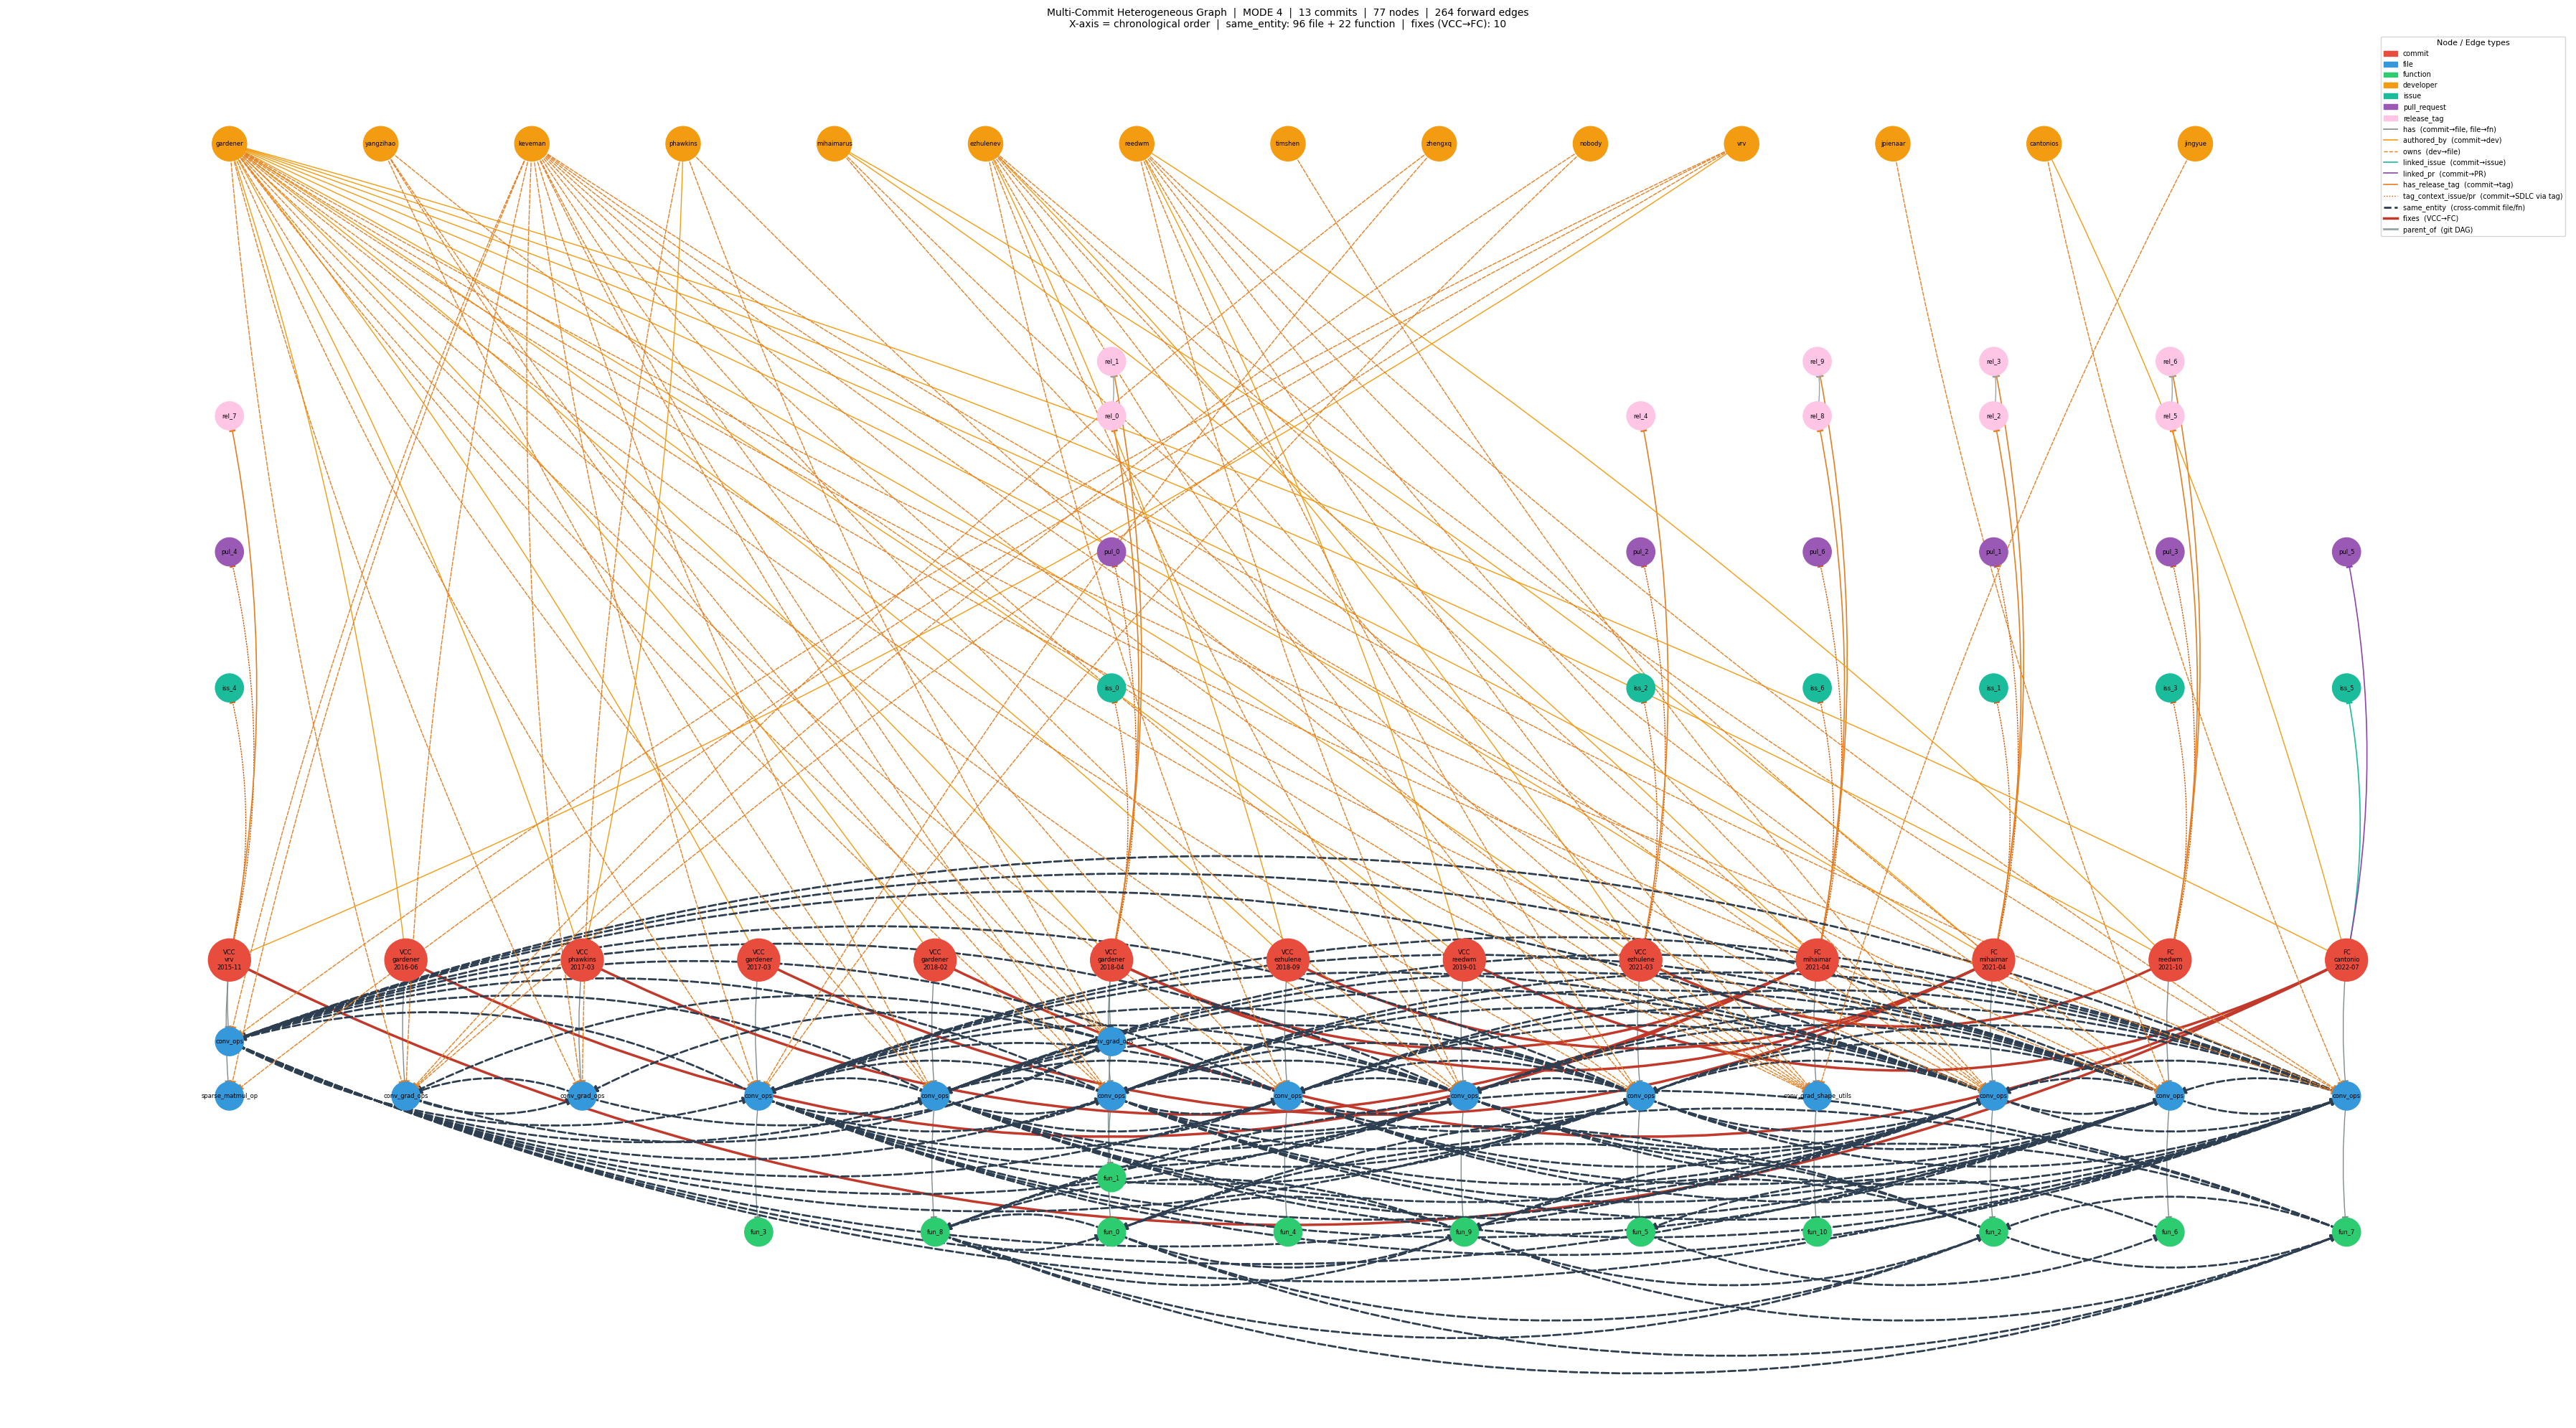

Saved to outputs/multi_commit_graph.png


In [7]:
# ── Draw ───────────────────────────────────────────────────────────────────────
# Reverse edges are drawn via their forward counterpart (flip=0 direction kept)
REVERSE_RELS = {'issue_of', 'pr_of', 'tag_of', 'referenced_by_pr', 'prev_tag',
                'prev_issue', 'prev_pr', 'tag_context_of', 'in_release'}

# Only skip relations that are truly redundant or too noisy to read:
#   - next_*/prev_* temporal chains between SDLC nodes (mode 4 tag chain kept via next_tag)
#   - affects_*/in_release (0 edges in mode 4 anyway)
#   - references_issue (PR→issue cross edges — clutters without adding commit connectivity)
# All commit→SDLC edges (linked_issue, linked_pr, has_release_tag,
# tag_context_pr, tag_context_issue) are KEPT so SDLC nodes are anchored.
SKIP_RELS = {'next_issue', 'next_pr', 'affects_pr', 'affects_issue', 'references_issue'}

G_vis = nx.DiGraph()
for nid, pos in node_pos.items():
    G_vis.add_node(nid, pos=pos, ntype=node_type[nid])

for et in mg.edge_types:
    src_t, rel, dst_t = et
    if rel in REVERSE_RELS or rel in SKIP_RELS:
        continue
    ei = mg[et].edge_index
    for k in range(ei.shape[1]):
        s = f'{src_t}_{ei[0,k].item()}'
        d = f'{dst_t}_{ei[1,k].item()}'
        if s in node_pos and d in node_pos:
            G_vis.add_edge(s, d, rel=rel)

pos_dict    = {n: d['pos'] for n, d in G_vis.nodes(data=True)}
node_colors = [COLOUR.get(G_vis.nodes[n]['ntype'], '#bdc3c7') for n in G_vis.nodes]
node_sizes  = [1800 if G_vis.nodes[n]['ntype'] == 'commit' else
               1200 if G_vis.nodes[n]['ntype'] == 'developer' else 800
               for n in G_vis.nodes]

fig, ax = plt.subplots(figsize=(36, 20))

# Draw edges grouped by relation type
edge_groups = {}
for u, v, d in G_vis.edges(data=True):
    edge_groups.setdefault(d['rel'], []).append((u, v))

STYLE_MAP = {
    'same_entity':       dict(width=2.0, style='dashed', rad=0.20),
    'fixes':             dict(width=2.5, style='solid',  rad=0.25),
    'parent_of':         dict(width=2.0, style='solid',  rad=0.20),
    'owns':              dict(width=1.0, style='dashed',  rad=0.05),
    'has_release_tag':   dict(width=1.2, style='solid',  rad=0.10),
    'linked_issue':      dict(width=1.2, style='solid',  rad=0.10),
    'linked_pr':         dict(width=1.2, style='solid',  rad=0.10),
    'tag_context_pr':    dict(width=1.0, style='dotted', rad=0.12),
    'tag_context_issue': dict(width=1.0, style='dotted', rad=0.12),
    'next_tag':          dict(width=1.0, style='solid',  rad=0.08),
}

for rel, edges in edge_groups.items():
    col  = EDGE_COLOUR.get(rel, '#95a5a6')
    s    = STYLE_MAP.get(rel, dict(width=1.0, style='solid', rad=0.05))
    nx.draw_networkx_edges(G_vis, pos_dict, edgelist=edges, edge_color=col,
                           style=s['style'], arrows=True, arrowsize=14,
                           width=s['width'],
                           connectionstyle=f'arc3,rad={s["rad"]}', ax=ax)

nx.draw_networkx_nodes(G_vis, pos_dict, node_color=node_colors,
                       node_size=node_sizes, ax=ax)
nx.draw_networkx_labels(G_vis, pos_dict,
                        labels={n: node_label.get(n, n) for n in G_vis.nodes},
                        font_size=6, ax=ax)

# Legend — node types
node_legend = [mpatches.Patch(color=c, label=nt) for nt, c in COLOUR.items()]
# Legend — edge types
edge_legend = [
    Line2D([0],[0], color=EDGE_COLOUR['has'],               lw=1.2,             label='has  (commit→file, file→fn)'),
    Line2D([0],[0], color=EDGE_COLOUR['authored_by'],       lw=1.2,             label='authored_by  (commit→dev)'),
    Line2D([0],[0], color=EDGE_COLOUR['owns'],              lw=1.0, ls='--',    label='owns  (dev→file)'),
    Line2D([0],[0], color=EDGE_COLOUR['linked_issue'],      lw=1.2,             label='linked_issue  (commit→issue)'),
    Line2D([0],[0], color=EDGE_COLOUR['linked_pr'],         lw=1.2,             label='linked_pr  (commit→PR)'),
    Line2D([0],[0], color=EDGE_COLOUR['has_release_tag'],   lw=1.2,             label='has_release_tag  (commit→tag)'),
    Line2D([0],[0], color=EDGE_COLOUR['tag_context_issue'], lw=1.0, ls=':',     label='tag_context_issue/pr  (commit→SDLC via tag)'),
    Line2D([0],[0], color=EDGE_COLOUR['same_entity'],       lw=2.0, ls='--',    label='same_entity  (cross-commit file/fn)'),
    Line2D([0],[0], color=EDGE_COLOUR['fixes'],             lw=2.5,             label='fixes  (VCC→FC)'),
    Line2D([0],[0], color=EDGE_COLOUR['parent_of'],         lw=2.0,             label='parent_of  (git DAG)'),
]
ax.legend(handles=node_legend + edge_legend, loc='upper right', fontsize=7,
          title='Node / Edge types', title_fontsize=8)

ax.set_title(
    f'Multi-Commit Heterogeneous Graph  |  MODE {MODE}  |  {len(COMMIT_HASHES)} commits  |  '
    f'{G_vis.number_of_nodes()} nodes  |  {G_vis.number_of_edges()} forward edges\n'
    f'X-axis = chronological order  |  '
    f'same_entity: {mg["file","same_entity","file"].edge_index.shape[1]} file + '
    f'{mg["function","same_entity","function"].edge_index.shape[1]} function  |  '
    f'fixes (VCC→FC): {mg["commit","fixes","commit"].edge_index.shape[1]}',
    fontsize=10)
ax.axis('off')
plt.tight_layout()
plt.savefig('../outputs/multi_commit_graph.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to outputs/multi_commit_graph.png')

In [8]:
# ── Edge attribute inspection ──────────────────────────────────────────────────
print('Cross-commit edge attributes:')
print()

print('(file, same_entity, file)  — [delta_complexity, delta_loc, delta_token_count, log1p(time_gap_days)]')
ea = mg['file', 'same_entity', 'file'].edge_attr
print(f'  shape: {tuple(ea.shape)}  min={ea.min():.3f}  max={ea.max():.3f}  mean={ea.mean():.3f}')
print(f'  sample row: {ea[0].tolist()}')
print()

print('(function, same_entity, function)  — [delta_complexity, delta_loc, log1p(time_gap_days)]')
ea = mg['function', 'same_entity', 'function'].edge_attr
print(f'  shape: {tuple(ea.shape)}  min={ea.min():.3f}  max={ea.max():.3f}  mean={ea.mean():.3f}')
if ea.shape[0] > 0:
    print(f'  sample row: {ea[0].tolist()}')
print()

print('(commit, fixes, commit)  — [log1p(days_vcc_to_fc)]')
ei = mg['commit', 'fixes', 'commit'].edge_index
ea = mg['commit', 'fixes', 'commit'].edge_attr
ci_tbl = tables['commit_info']
print(f'  shape: {tuple(ea.shape)}')
for k in range(ei.shape[1]):
    s, d = ei[0,k].item(), ei[1,k].item()
    sh, dh = COMMIT_HASHES[s], COMMIT_HASHES[d]
    st = ci_tbl[ci_tbl['hash']==sh]['commit_type'].values[0] if len(ci_tbl[ci_tbl['hash']==sh]) else '?'
    dt = ci_tbl[ci_tbl['hash']==dh]['commit_type'].values[0] if len(ci_tbl[ci_tbl['hash']==dh]) else '?'
    days = float(np.expm1(ea[k,0]))
    print(f'  [{s}] {sh[:12]} ({st}) → [{d}] {dh[:12]} ({dt})  log_days={ea[k,0]:.3f}  ({days:.0f} days)')

Cross-commit edge attributes:

(file, same_entity, file)  — [delta_complexity, delta_loc, delta_token_count, log1p(time_gap_days)]
  shape: (96, 4)  min=-7761.000  max=7761.000  mean=1.625
  sample row: [53.0, 541.0, 3403.0, 6.990256309509277]

(function, same_entity, function)  — [delta_complexity, delta_loc, log1p(time_gap_days)]
  shape: (22, 3)  min=-204.000  max=204.000  mean=2.112
  sample row: [29.0, 200.0, 6.990256309509277]

(commit, fixes, commit)  — [log1p(days_vcc_to_fc)]
  shape: (10, 1)
  [0] a5a51ad3a120 (VCC) → [12] fca9874a9b42 (FC)  log_days=6.990  (1085 days)
  [4] 19dd9342e7bc (VCC) → [12] fca9874a9b42 (FC)  log_days=7.317  (1505 days)
  [5] e961e063a278 (VCC) → [12] fca9874a9b42 (FC)  log_days=7.475  (1762 days)
  [0] a5a51ad3a120 (VCC) → [1] b12aa1d44352 (FC)  log_days=6.990  (1085 days)
  [2] bc6e0c471c4d (VCC) → [1] b12aa1d44352 (FC)  log_days=7.311  (1496 days)
  [3] 3b9c747d71f3 (VCC) → [1] b12aa1d44352 (FC)  log_days=6.843  (936 days)
  [6] 7b8db6083b34 (VCC)

In [9]:
# ── Node label assignments (for GNN training) ─────────────────────────────────
# Each commit node gets a binary VCC label (1 = VCC, 0 = FC / unknown)
ci_tbl = tables['commit_info']
labels = []
for h in COMMIT_HASHES:
    row = ci_tbl[ci_tbl['hash'] == h]
    ctype = row['commit_type'].values[0] if len(row) else 'unknown'
    labels.append(1 if str(ctype).upper() == 'VCC' else 0)

mg['commit'].y = torch.tensor(labels, dtype=torch.long)

print('Commit node labels (0=FC/unknown, 1=VCC):')
for i, (h, lbl) in enumerate(zip(COMMIT_HASHES, labels)):
    row = ci_tbl[ci_tbl['hash'] == h]
    ctype  = row['commit_type'].values[0] if len(row) else '?'
    author = row['author'].values[0].split('@')[0] if len(row) else '?'
    date   = row['author_date'].values[0][:10] if len(row) else '?'
    print(f'  commit[{i:2d}] {h[:12]}  y={lbl}  ({ctype:5})  {author:<25} {date}')

print(f'\nVCC count: {sum(labels)}/{len(labels)}  ({100*sum(labels)/len(labels):.0f}%)')
print(f'\nmg["commit"].y shape: {mg["commit"].y.shape}')

Commit node labels (0=FC/unknown, 1=VCC):
  commit[ 0] a5a51ad3a120  y=1  (VCC  )  gardener                  2018-04-30
  commit[ 1] b12aa1d44352  y=0  (FC   )  mihaimaruseac             2021-04-19
  commit[ 2] bc6e0c471c4d  y=1  (VCC  )  gardener                  2017-03-15
  commit[ 3] 3b9c747d71f3  y=1  (VCC  )  ezhulenev                 2018-09-26
  commit[ 4] 19dd9342e7bc  y=1  (VCC  )  phawkins                  2017-03-06
  commit[ 5] e961e063a278  y=1  (VCC  )  gardener                  2016-06-22
  commit[ 6] 7b8db6083b34  y=1  (VCC  )  ezhulenev                 2021-03-19
  commit[ 7] e7f497570abb  y=0  (FC   )  reedwm                    2021-10-20
  commit[ 8] 4213ac97be44  y=1  (VCC  )  vrv                       2015-11-16
  commit[ 9] 611d80db29dd  y=0  (FC   )  cantonios                 2022-07-25
  commit[10] 8722aeebdf82  y=1  (VCC  )  gardener                  2018-02-22
  commit[11] ec81825aaf7e  y=1  (VCC  )  reedwm                    2019-01-08
  commit[12] fca9874a9